In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [2]:
rng = np.random.default_rng(123)

n= 100_000

In this case the conditional mean of $X$ and $W$ given $Z$ is linear in $Z$:

$ \mathbb{E}[X|Z]=z$  

$ \mathbb{E}[W|Z]=z$ 


Clearly $X$ and $W$ are independent once we know $Z$:

$ f_x(a)=P(Z+T=a)=\sum_Z P(T =a -z|Z=z)P(Z=z) \, dz $ thus $f_{x|Z=z}(a)=P(T=a-z)$

and,

$ f_w(a)=P(Z+R=a)=\sum_Z P(R =a -z|Z=z)P(Z=z) \, dz $ thus $f_{x|Z=z}(a)=P(R=a-z)$

and $R$ and $T$ are two indpendent random variables $N(0,4)$


In [3]:
z = rng.integers(1,21,size=n)

x = z+ rng.normal(loc=0, scale=2,size = n)

w = z+ rng.normal(loc=0, scale=2,size = n)

df= pd.DataFrame({'x':x,
                  'z':z,
                  'w':w})

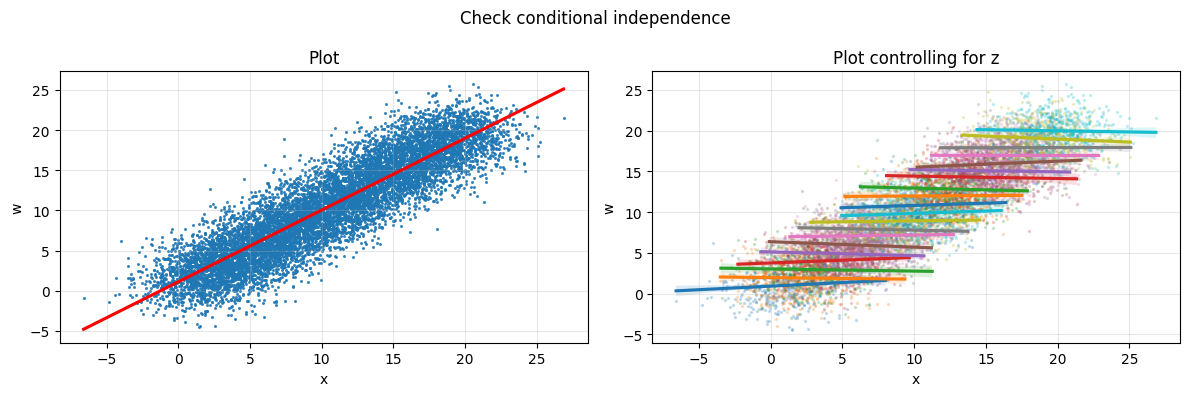

In [4]:
fig, ax = plt.subplots(1,2,figsize=(12,4))

sns.regplot(data=df.iloc[:10000,:],x='x',y='w',line_kws={'color':'red'},scatter_kws={'s':1.5}, ax=ax[0])

ax[0].grid(alpha=0.3)

ax[0].set_title('Plot')

for _,dataframe in df.iloc[:10000,:].groupby('z'):

    sns.regplot(data=dataframe,x='x',y='w',scatter_kws={'s':2,'alpha':0.2}, ax=ax[1])

ax[1].grid(alpha=0.3)

ax[1].set_title('Plot controlling for z')

fig.suptitle('Check conditional independence')

plt.tight_layout()

plt.show()



Once we control for $Z$, $X$ does not give us any additional information on $W$ and indeed the coefficient is 0.

In [5]:
y = 3*x-z+10*w+rng.normal(loc=0,scale=1,size=n)

In [6]:
j=100

cuts=np.unique(np.round(np.linspace(1000, n, num=j)).astype(int))

x_coefs_L=np.zeros(j)

z_coefs_L=np.zeros(j)

x_coefs_S=np.zeros(j)

z_coefs_S=np.zeros(j)

for i in range(j):

    cut = cuts[i]

    modello_L=sm.OLS(endog=y[:cut], exog=sm.add_constant(data=df.iloc[:cut,:])).fit()

    x_coefs_L[i] = modello_L.params['x']

    z_coefs_L[i] = modello_L.params['z']

    
    modello_S=sm.OLS(endog=y[:cut], exog=sm.add_constant(data=df.iloc[:cut,:2])).fit()

    x_coefs_S[i] = modello_S.params['x']

    z_coefs_S[i] = modello_S.params['z']



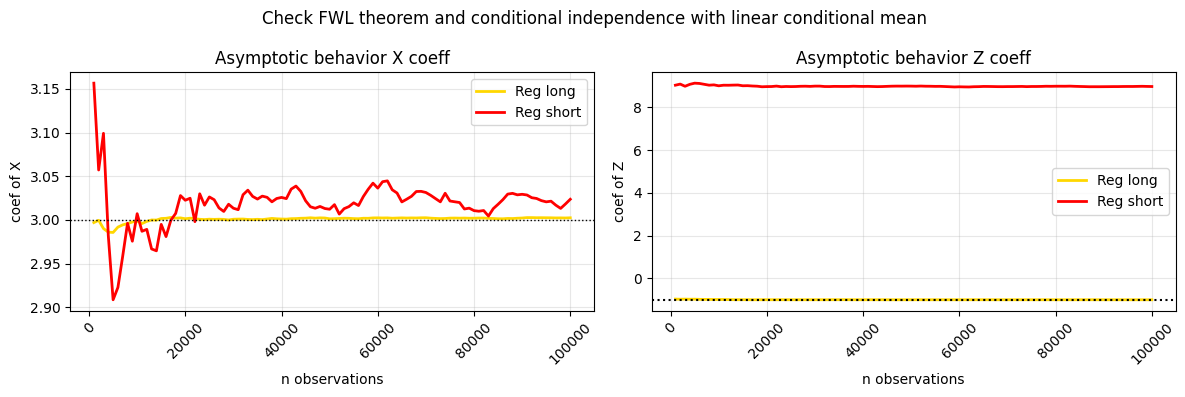

In [7]:
fig,ax=plt.subplots(1,2,figsize=(12,4))

ax[0].plot(cuts,x_coefs_L,color='gold',label='Reg long',linewidth=2)

ax[0].plot(cuts,x_coefs_S,color='red',label='Reg short',linewidth=2)

ax[0].axhline(3,linestyle=':',color='black',linewidth=1)

ax[0].grid(alpha=0.3)

ax[0].tick_params(axis='x', rotation=45)

ax[0].legend()

ax[0].set_xlabel('n observations')

ax[0].set_ylabel('coef of X')

ax[0].set_title('Asymptotic behavior X coeff')

ax[1].plot(cuts,z_coefs_L,color='gold',label='Reg long',linewidth=2)

ax[1].plot(cuts,z_coefs_S,color='red',label='Reg short',linewidth=2)

ax[1].axhline(-1,linestyle=':',linewidth=1.5,color='black')

ax[1].grid(alpha=0.3)

ax[1].tick_params(axis='x', rotation=45)

ax[1].legend()

ax[1].set_xlabel('n observations')

ax[1].set_ylabel('coef of Z')

ax[1].set_title('Asymptotic behavior Z coeff')

fig.suptitle('Check FWL theorem and conditional independence with linear conditional mean')

plt.tight_layout()

plt.show()

Disclaimer: for sure there is a faster way but I don't know it and what is written below could even be wrong

Assuming linearity of $\mathbb{E}[X|Z]$ and $\mathbb{E}[X|Z]$ we have:

$ \beta^L = (\mathbf{X'}M_{zw}'M_{zw}\mathbf{X})^{-1}(\mathbf{X'}M_{zw}'M_{zw}y) = (\mathbf{X'}M_{z}'M_{z}\mathbf{X})^{-1}(\mathbf{X'}M_{z}'M_{z}y) = \beta^S $

To show this (for the general case where $\mathbf{Z}$ and $\mathbf{W}$ are matrix of dimension respectively $ n \times k$ and $ n \times j$):

$ \underbrace{\begin{bmatrix}
    \mathbf{Z} & M_z\mathbf{W}
\end{bmatrix}}_{A} = 
\underbrace{\begin{bmatrix}
    \mathbf{Z} & \mathbf{W}
\end{bmatrix}}_{B}
\underbrace{\begin{bmatrix}
    I_k & -(\mathbf{Z}'\mathbf{Z})^{-1}\mathbf{Z}'\mathbf{W} \\
    0 & I_j
\end{bmatrix}}_{R} $ 

and $R$ is invertible therefore the columns of $A$ are all linear combinations of the columns of $B$ and viceversa. Thus, $col(A)$ and $col(B)$ span the same space. Therefore:

$P_{zw}\mathbf{X} = P_{zM_zw}\mathbf{X}$ 

Moreover:

$P_{zM_zw}\mathbf{X}=
\begin{bmatrix}
    \mathbf{Z} & M_z\mathbf{W}
\end{bmatrix}
\left(\begin{bmatrix}
\mathbf{Z}'\mathbf{Z} & \mathbf{Z}'M_z\mathbf{W} \\
\mathbf{W}'M_z'\mathbf{Z} & \mathbf{W}'M_z\mathbf{W}
\end{bmatrix}\right)^{-1}
\begin{bmatrix}
    \mathbf{Z}' & M_zw'
\end{bmatrix}' $

and $ \mathbf{Z}'M_z =0$ thus:

$P_{zM_zw}\mathbf{X}=
\begin{bmatrix}
    \mathbf{Z} & M_z\mathbf{W}
\end{bmatrix}
\begin{bmatrix}
(\mathbf{Z}'\mathbf{Z})^{-1} & 0 \\
0 & (\mathbf{W}'M_z\mathbf{W})^{-1}
\end{bmatrix}^{-1}
\begin{bmatrix}
    \mathbf{Z}' & M_z\mathbf{W}
\end{bmatrix}' $

$P_{zM_zw}\mathbf{X}= \mathbf{Z}(\mathbf{Z}'\mathbf{Z})^{-1}\mathbf{Z}' + M_z\mathbf{W}(\mathbf{W}'M_z\mathbf{W})^{-1}\mathbf{W}'M_z$

$ \implies M_{zM_zw}\mathbf{X} = (I_n - P_{zM_zw})\mathbf{X} = \mathbf{X} -\mathbf{Z}(\mathbf{Z}'\mathbf{Z})^{-1}\mathbf{Z}''\mathbf{X}- M_z\mathbf{W}(\mathbf{W}'M_z\mathbf{W})^{-1}\mathbf{W}'M_z\mathbf{X}$

assuming linearity of the conditional expectations and due to conditional independence given $Z$,we have:

$\mathbf{W}'M_z'M_z\mathbf{X}=\mathbf{W}'M_z\mathbf{X}=0$ and therefore:

$(\mathbf{X'}M_{zw}'M_{zw}\mathbf{X})^{-1}(\mathbf{X'}M_{zw}'M_{zw}y) = (\mathbf{X'}M_{z}'M_{z}\mathbf{X})^{-1}(\mathbf{X'}M_{z}'M_{z}y)$

## Modello 2

In [8]:
t = rng.normal(loc=5,scale=1,size=n)

r = rng.normal(loc=5,scale=1,size=n)

In [9]:
x = (z**2)*t

w=(z**2)*r

df= pd.DataFrame({'x':x,
                  'z':z,
                  'w':w})

If the conditional means are not linear for example:

$ \mathbb{E}[X|Z]=\mathbb{E}[Z^2T|Z] = Z^2\mathbb{E}[T|Z]= Z^2 \mu_T$


$ \mathbb{E}[W|Z]=z\mathbb{E}[Z^2R|Z]= Z^2\mathbb{E}[R|Z]= Z^2 \mu_R$ 

I know that residuals $ \mathbb{E}[(X-\mathbb{E}[X|Z])(W-\mathbb{E}[W|Z])|Z] = \mathbb{E}[\epsilon_{X|Z}^*\epsilon_{W|Z}^*|Z]= 0$.

And $ \mathbb{E}[\epsilon_{X|Z}^*\epsilon_{W|Z}^*|Z]= 0 \implies \mathbb{E}[\epsilon_{X|Z}^*\epsilon_{W|Z}^*]= 0$

If conditional mean were linear i could have gotten to $\mathbf{X}'M_z'M_z\mathbf{W}=0$  where $\mathbf{X},\mathbf{W}$ are vectors with $n$ entries and $n \to \infty$


But given that the conditional means are not linear, then $\mathbf{X}'M_z'M_z\mathbf{W}\neq 0$ (maybe??).

Let' see what we are doing implicitly:

we are assuming that the linear projection of $X$ on $Z$ and of $W$ on $Z$ are orthogonal, but are they?

In this case the short regression does not seem to work.

Now we can check what happens when we regress the linear residuals and what happens when we chek when we regress on the true residuals (that in this case are known because data is generated).

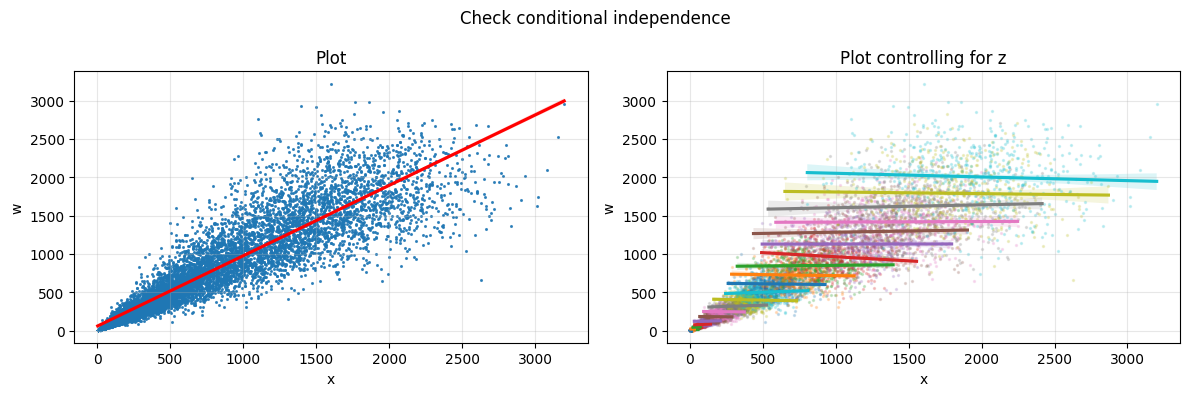

In [10]:
fig, ax = plt.subplots(1,2,figsize=(12,4))

sns.regplot(data=df.iloc[:10000,:],x='x',y='w',line_kws={'color':'red'},scatter_kws={'s':1.5}, ax=ax[0])

ax[0].grid(alpha=0.3)

ax[0].set_title('Plot')

for _,dataframe in df.iloc[:10000,:].groupby('z'):

    sns.regplot(data=dataframe,x='x',y='w',scatter_kws={'s':2,'alpha':0.2}, ax=ax[1])

ax[1].grid(alpha=0.3)

ax[1].set_title('Plot controlling for z')

fig.suptitle('Check conditional independence')

plt.tight_layout()

plt.show()

In [11]:
y= 3*x -z+10*w+rng.normal(loc=0,scale=1,size=n) 

In [12]:
coef_reg_xz = sm.OLS(endog=x,exog=z).fit().params[0]

mzx =x- z*coef_reg_xz

res_x_star = x-(z**2)*5


In [13]:
coef_reg_wz = sm.OLS(endog=w,exog=z).fit().params[0]

mzw =w- z*coef_reg_wz

res_w_star = w-(z**2)*5

In [14]:
print(f'Expected product of linear residuals: {(sum(mzx*mzw))/n} \n')

print(f'Expected product of star residuals: {(sum(res_x_star*res_w_star))/n} \n')

Expected product of linear residuals: 56386.08123280293 

Expected product of star residuals: -134.495375218376 



We can quickly check that the linear residuals are not orthogonal, this is because it is the product of the real conditinal expecations of $X$ and $W$ that is equal to 0, not the product of the linear projections residuals.

In [15]:
pred_y_star = (3*(z**2)*5)-z+(10*(z**2)*5)

res_y_star = y-pred_y_star


In [16]:
df['resx'] = res_x_star

In [17]:
j=30

cuts=np.unique(np.round(np.linspace(1000, n, num=j)).astype(int))

x_coefs_L=np.zeros(j)

z_coefs_L=np.zeros(j)

x_coefs_S=np.zeros(j)

z_coefs_S=np.zeros(j)

x_coefs_star=np.zeros(j)

for i in range(j):

    cut = cuts[i]

    modello_L=sm.OLS(endog=y[:cut], exog=sm.add_constant(data=df.iloc[:cut,:3])).fit()

    x_coefs_L[i] = modello_L.params['x']

    z_coefs_L[i] = modello_L.params['z']

    
    modello_S=sm.OLS(endog=y[:cut], exog=sm.add_constant(data=df.iloc[:cut,:2])).fit()

    x_coefs_S[i] = modello_S.params['x']

    z_coefs_S[i] = modello_S.params['z']

    modello_star = sm.OLS(endog=res_y_star[:cut], exog=sm.add_constant(data=df.iloc[:cut,3])).fit()

    x_coefs_star[i] = modello_star.params['resx']

 

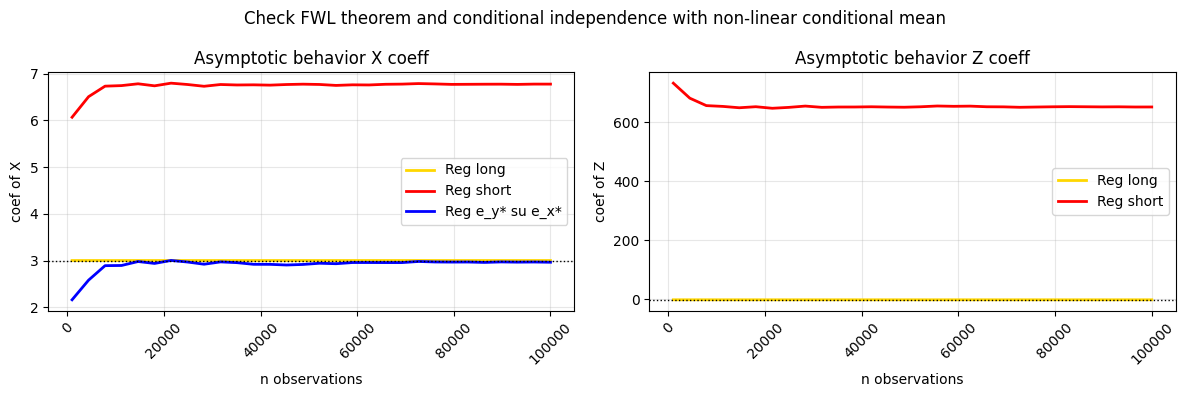

In [18]:
fig,ax=plt.subplots(1,2,figsize=(12,4))

ax[0].plot(cuts,x_coefs_L,color='gold',label='Reg long',linewidth=2)

ax[0].plot(cuts,x_coefs_S,color='red',label='Reg short',linewidth=2)

ax[0].plot(cuts,x_coefs_star, color='blue',label='Reg e_y* su e_x*',linewidth=2)

ax[0].axhline(3,linestyle=':',color='black',linewidth=1)

ax[0].grid(alpha=0.3)

ax[0].tick_params(axis='x', rotation=45)

ax[0].legend()

ax[0].set_xlabel('n observations')

ax[0].set_ylabel('coef of X')

ax[0].set_title('Asymptotic behavior X coeff')

ax[1].plot(cuts,z_coefs_L,color='gold',label='Reg long',linewidth=2)

ax[1].plot(cuts,z_coefs_S,color='red',label='Reg short',linewidth=2)

ax[1].axhline(-1,linestyle=':',linewidth=1,color='black')

ax[1].grid(alpha=0.3)

ax[1].tick_params(axis='x', rotation=45)

ax[1].legend()

ax[1].set_xlabel('n observations')

ax[1].set_ylabel('coef of Z')

ax[1].set_title('Asymptotic behavior Z coeff')

fig.suptitle('Check FWL theorem and conditional independence with non-linear conditional mean')

plt.tight_layout()

plt.show()

In conclusion, in order to directly exploit conditional independence and FWL in linear regression, it is necessary that the conditional means of $X$ and $W$ given $Z$ are linear. In this case by conditional indpendece and FWL imply that the long regression coefficient and the short regression coefficient for $\beta$ are equal. Otherwise, the FWL would only imply the equvalence between the $\beta$ of the long regression with the $\beta$ of the regression $ M_{zw}Y \sim M_{zw}X $.  

If we could not observe $W$ (thus motivating our need to estimate $\beta$ not using that variable) we would need to estimate the conditional expectations $\mathbb{E}[Y|Z]$ and $\mathbb{E}[X|Z]$ in a nonparametric way and then apply a regression on the residuals (partialling out the estimated conditional means of both $Y$ and $W$ with respect to $Z$).

This is because, once we work with residuals after conditioning on $Z$, the linear projection interpretation of the Frisch-Waugh-Lovell theorem only holds under correct specification of the conditional expectations.

In the case where all relationships are linear, the (large-sample) equivalence between the coefficient $\beta$ from the full regression and the coefficient from the reduced regression is given by:

$ \beta^L = (\mathbf{X'}M_{zw}'M_{zw}\mathbf{X})^{-1}(\mathbf{X'}M_{zw}'M_{zw}y) = (\mathbf{X'}M_{z}'M_{z}\mathbf{X})^{-1}(\mathbf{X'}M_{z}'M_{z}y) = \beta^S $

If conditional means are not linear then we have:

$ \beta^L = (\mathbf{X'}M_{zw}'M_{zw}\mathbf{X})^{-1}(\mathbf{X'}M_{zw}'M_{zw}y) = (\epsilon_{X|Z}^{*'}\epsilon_{X|Z}^*)^{-1}(\epsilon_{X|Z}^{*'}\epsilon_{y|Z}^*)$

To see why this last equality holds, we can see that in the first model: 

$ y = \beta x +\gamma z + \theta w +\epsilon$

expectation conditional to $Z$ is:

$ \mathbb{E}[y|Z]=\beta \mathbb{E}[X|Z] + \gamma z + \theta \mathbb{E}[W|Z] +0$

and subtracting the two models:

$ y-\mathbb{E}[y|Z] = \beta (x-\mathbb{E}[X|Z])+ \theta (w-\mathbb{E}[W|Z]) +\epsilon$

therefore, we can estimate $\beta$ consistently using OLS in this model, and the resulting estimate of $\beta$ is equal to the one obtained by regressing only on the starred residuals of $X$. Indeed:

$ \begin{bmatrix}
    \beta \\ 
    \theta 
\end{bmatrix} = 
\left(\begin{bmatrix}
   \epsilon_{X|Z}^{*'} \\
   \epsilon_{W|Z}^{*'}
\end{bmatrix}
\begin{bmatrix}
   \epsilon_{X|Z}^{*} & \epsilon_{W|Z}^{*}
\end{bmatrix}\right)^{-1}
\left(\begin{bmatrix}
   \epsilon_{X|Z}^{*'} \\
   \epsilon_{W|Z}^{*'}
\end{bmatrix}
y\right) $

given conditional independence we have that $\mathbb{E}[\epsilon_{X|Z}^*\epsilon_{W|Z}^*]= 0$ thus we the equation is equal to:

$
\left(
\begin{bmatrix}
   \epsilon_{X|Z}^{*'}\epsilon_{X|Z}^{*} & 0 \\
   0 & \epsilon_{W|Z}^{*'}\epsilon_{W|Z}^{*}
\end{bmatrix}
\right)^{-1}
\begin{bmatrix}
   \epsilon_{X|Z}^{*'} \\
   \epsilon_{W|Z}^{*'}
\end{bmatrix} y 
$

The inverse of a diagonal matrix is a diagonal matrix with the inverse of the entries,the estimate for $ \beta$ is:

$\beta = (\epsilon_{X|Z}^{*'}\epsilon_{X|Z}^{*})^{-1}(\epsilon_{X|Z}^{*'} y)$



In [19]:
dataframe_completo=pd.DataFrame({'Y':y,
                                 'X':x,
                                 'Z':z,
                                 'W':w})

In [20]:
# loop takes a bit 

deep_list = [2,3,4]

x_coefs_dml=np.zeros((j,len(deep_list)))

for f in range(len(deep_list)):

    deep = deep_list[f]

    for i in range(j):

        cut = cuts[i]


        dml_data = DoubleMLData(dataframe_completo.iloc[:cut,:], y_col="Y", d_cols="X", x_cols=['Z'])

        dml_plr = DoubleMLPLR(dml_data,
                              ml_l=LinearRegression(),
                              ml_m=RandomForestRegressor(n_estimators=100, max_depth=deep),
                              n_folds=5).fit()

        x_coefs_dml[i,f]=dml_plr.coef[0]

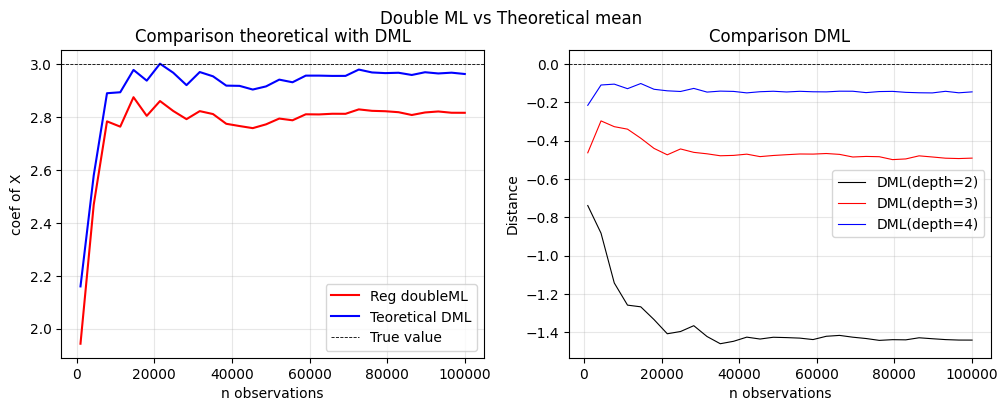

In [21]:
colors=['black','red','blue','purple']

fig , ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(cuts,x_coefs_dml[:,len(deep_list)-1],color='red',label='Reg doubleML')

ax[0].plot(cuts,x_coefs_star,color='blue',label='Teoretical DML')

ax[0].axhline(3,color='black',linewidth=0.6,label='True value',linestyle='--')

ax[0].grid(alpha=0.3)

ax[0].legend()

ax[0].set_title('Comparison theoretical with DML')

ax[0].set_xlabel('n observations')

ax[0].set_ylabel('coef of X')

for i in range(len(deep_list)):

    ax[1].plot(cuts,x_coefs_dml[:,i]-x_coefs_star,color=colors[i],label=f'DML(depth={i+2})',linewidth=0.8)

ax[1].axhline(0,color='black',linewidth=0.6,linestyle='--')

ax[1].grid(alpha=0.3)

ax[1].legend()

ax[1].set_title('Comparison DML')

ax[1].set_xlabel('n observations')

ax[1].set_ylabel('Distance')

fig.suptitle("Double ML vs Theoretical mean")

plt.show()